In [1]:
!pip -q install scipy scikit-learn pandas matplotlib tqdm

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import qmc
from scipy.stats import pearsonr
from sklearn.metrics import mutual_info_score

from tqdm.notebook import tqdm

import pickle
import os


In [3]:
# -----------------------------
# Library Parameters
# -----------------------------

STREAM_LENGTH = 512

VALUES = np.round(np.arange(0.00, 1.01, 0.01), 2)

NUM_VALUES = len(VALUES)

SEED = 42

print(f"Values : {NUM_VALUES}")
print(f"Stream Length : {STREAM_LENGTH}")

Values : 101
Stream Length : 512


In [4]:
def generate_stream_pair(probability,
                         length=1000,
                         seed=42):
    """
    Generates two Sobol stochastic bitstreams
    using a 2D scrambled Sobol sequence.
    """

    sobol = qmc.Sobol(
        d=2,
        scramble=True,
        seed=seed
    )

    points = sobol.random(length)

    stream_A = (points[:,0] < probability).astype(np.uint8)

    stream_B = (points[:,1] < probability).astype(np.uint8)

    return stream_A, stream_B


In [5]:
library = {}

for idx, value in enumerate(tqdm(VALUES)):

    A, B = generate_stream_pair(
        value,
        STREAM_LENGTH,
        SEED + idx      # different scramble for every value
    )

    library[value] = {
        "A": A,
        "B": B
    }

print("Library Generated!")

print("Example Keys")

print(list(library.keys())[:5])

  0%|          | 0/101 [00:00<?, ?it/s]

Library Generated!
Example Keys
[np.float64(0.0), np.float64(0.01), np.float64(0.02), np.float64(0.03), np.float64(0.04)]


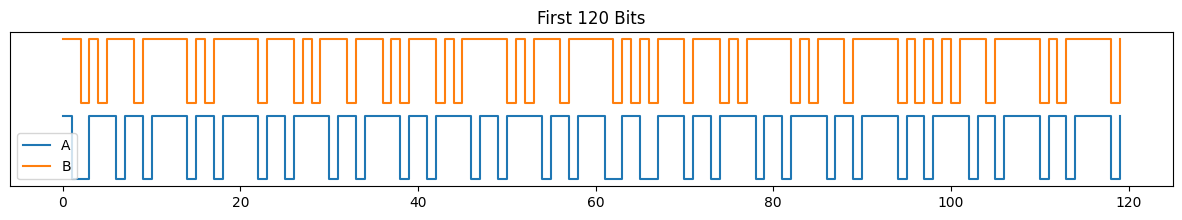

In [6]:
example = 0.73

A = library[example]["A"]
B = library[example]["B"]

plt.figure(figsize=(15,2))

plt.plot(A[:120], drawstyle="steps-post", label="A")

plt.plot(B[:120]+1.2,
         drawstyle="steps-post",
         label="B")

plt.yticks([])

plt.title("First 120 Bits")

plt.legend()

plt.show()

In [7]:
os.makedirs("library", exist_ok=True)

with open("library/sobol_library.pkl","wb") as f:
    pickle.dump(library,f)

print("Saved.")


Saved.


In [8]:
os.makedirs("library", exist_ok=True)

with open("library/sobol_library.pkl","wb") as f:
    pickle.dump(library,f)

print("Saved.")

Saved.


In [9]:
sanity_results = []

for value in VALUES:

    A = library[value]["A"]

    B = library[value]["B"]

    expected = int(round(value * STREAM_LENGTH))

    actual_A = int(np.sum(A))

    actual_B = int(np.sum(B))

    sanity_results.append([
        value,
        expected,
        actual_A,
        actual_B,
        actual_A-expected,
        actual_B-expected
    ])

sanity_df = pd.DataFrame(

    sanity_results,

    columns=[
        "Value",
        "Expected Ones",
        "A Ones",
        "B Ones",
        "A Error",
        "B Error"
    ]
)

sanity_df.head()

,Value,Expected Ones,A Ones,B Ones,A Error,B Error
0,0.00,0,0,0,0,0
1,0.01,5,5,5,0,0
2,0.02,10,10,10,0,0
3,0.03,15,15,16,0,1
4,0.04,20,20,20,0,0


In [10]:
print(sanity_df.describe())

print()

print("Maximum Absolute Error A:",
      sanity_df["A Error"].abs().max())

print("Maximum Absolute Error B:",
      sanity_df["B Error"].abs().max())

            Value  Expected Ones      A Ones      B Ones     A Error  \
count  101.000000     101.000000  101.000000  101.000000  101.000000   
mean     0.500000     256.000000  256.059406  255.920792    0.059406   
std      0.293002     150.036262  150.061042  149.936766    0.465226   
min      0.000000       0.000000    0.000000    0.000000   -1.000000   
25%      0.250000     128.000000  128.000000  128.000000    0.000000   
50%      0.500000     256.000000  256.000000  256.000000    0.000000   
75%      0.750000     384.000000  384.000000  384.000000    0.000000   
max      1.000000     512.000000  512.000000  512.000000    1.000000   

          B Error  
count  101.000000  
mean    -0.079208  
std      0.462237  
min     -1.000000  
25%      0.000000  
50%      0.000000  
75%      0.000000  
max      1.000000  

Maximum Absolute Error A: 1
Maximum Absolute Error B: 1


In [11]:
mi_results = []

for value in VALUES:

    A = library[value]["A"]

    B = library[value]["B"]

    mi = mutual_info_score(A,B)

    mi_results.append(mi)

mi_df = pd.DataFrame({

    "Value":VALUES,

    "Mutual Information":mi_results

})

mi_df.head()

,Value,Mutual Information
0,0.00,0.000000
1,0.01,0.000096
2,0.02,0.000389
3,0.03,0.000944
4,0.04,0.001449


In [12]:
pearson_results = []

for value in VALUES:

    A = library[value]["A"]

    B = library[value]["B"]

    corr,_ = pearsonr(A,B)

    pearson_results.append(corr)

pearson_df = pd.DataFrame({

    "Value":VALUES,

    "Pearson":pearson_results

})

pearson_df.head()

/tmp/ipykernel_1447/2046383151.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr,_ = pearsonr(A,B)


,Value,Pearson
0,0.00,NaN
1,0.01,-0.009862
2,0.02,-0.019920
3,0.03,-0.031202
4,0.04,0.063415


In [13]:
hamming_results = []

for value in VALUES:

    A = library[value]["A"]

    B = library[value]["B"]

    distance = np.mean(A != B)

    hamming_results.append(distance)

hamming_df = pd.DataFrame({

    "Value":VALUES,

    "Hamming Distance":hamming_results

})

hamming_df.head()

,Value,Hamming Distance
0,0.00,0.000000
1,0.01,0.019531
2,0.02,0.039062
3,0.03,0.060547
4,0.04,0.070312


In [14]:

summary = pd.DataFrame({

    "Value":VALUES,

    "Pearson":pearson_results,

    "Mutual Information":mi_results,

    "Hamming Distance":hamming_results

})

summary.head()

,Value,Pearson,Mutual Information,Hamming Distance
0,0.00,NaN,0.000000,0.000000
1,0.01,-0.009862,0.000096,0.019531
2,0.02,-0.019920,0.000389,0.039062
3,0.03,-0.031202,0.000944,0.060547
4,0.04,0.063415,0.001449,0.070312


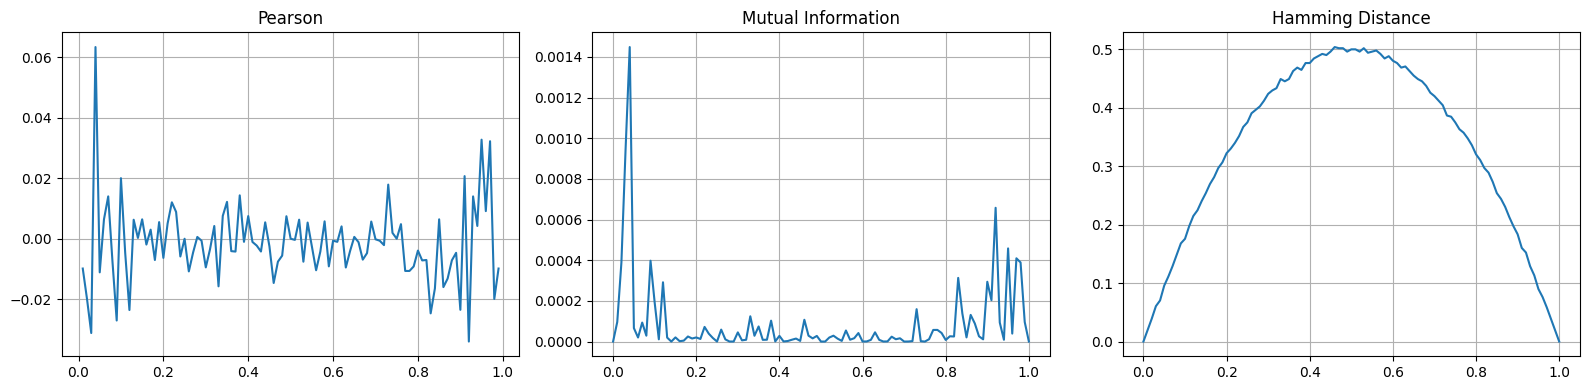

In [15]:
plt.figure(figsize=(16,4))

plt.subplot(131)
plt.plot(summary["Value"],
         summary["Pearson"])
plt.grid(True)
plt.title("Pearson")

plt.subplot(132)
plt.plot(summary["Value"],
         summary["Mutual Information"])
plt.grid(True)
plt.title("Mutual Information")

plt.subplot(133)
plt.plot(summary["Value"],
         summary["Hamming Distance"])
plt.grid(True)
plt.title("Hamming Distance")

plt.tight_layout()

plt.show()

In [16]:
results = []

for a in tqdm(VALUES):

    streamA = library[a]["A"]

    for b in VALUES:

        streamB = library[b]["B"]

        product_stream = streamA & streamB

        measured = np.sum(product_stream) / STREAM_LENGTH

        expected = a * b

        error = measured - expected

        results.append([
            a,
            b,
            expected,
            measured,
            error,
            abs(error)
        ])

mult_df = pd.DataFrame(

    results,

    columns=[
        "A",
        "B",
        "Expected",
        "Measured",
        "Error",
        "Absolute Error"
    ]
)

mult_df.head()

  0%|          | 0/101 [00:00<?, ?it/s]

,A,B,Expected,Measured,Error,Absolute Error
0,0.0,0.00,0.0,0.0,0.0,0.0
1,0.0,0.01,0.0,0.0,0.0,0.0
2,0.0,0.02,0.0,0.0,0.0,0.0
3,0.0,0.03,0.0,0.0,0.0,0.0
4,0.0,0.04,0.0,0.0,0.0,0.0


In [17]:

mae = mult_df["Absolute Error"].mean()

rmse = np.sqrt(np.mean(mult_df["Error"]**2))

max_error = mult_df["Absolute Error"].max()

print("MAE :", mae)

print("RMSE:", rmse)

print("Max :", max_error)

MAE : 0.0010846387609057939
RMSE: 0.0013711802601208741
Max : 0.0051875000000000115


In [18]:
self_df = mult_df[mult_df["A"]==mult_df["B"]]

self_df.head()

,A,B,Expected,Measured,Error,Absolute Error
0,0.00,0.00,0.0000,0.000000,0.000000,0.000000
102,0.01,0.01,0.0001,0.000000,-0.000100,0.000100
204,0.02,0.02,0.0004,0.000000,-0.000400,0.000400
306,0.03,0.03,0.0009,0.000000,-0.000900,0.000900
408,0.04,0.04,0.0016,0.003906,0.002306,0.002306


In [19]:
mult_df.sort_values(

    "Absolute Error",

    ascending=False

).head(20)

,A,B,Expected,Measured,Error,Absolute Error
4676,0.46,0.30,0.1380,0.132812,-0.005188,0.005188
8850,0.87,0.63,0.5481,0.542969,-0.005131,0.005131
7857,0.77,0.80,0.6160,0.621094,0.005094,0.005094
7100,0.70,0.30,0.2100,0.205078,-0.004922,0.004922
3360,0.33,0.27,0.0891,0.093750,0.004650,0.004650
4692,0.46,0.46,0.2116,0.207031,-0.004569,0.004569
3524,0.34,0.90,0.3060,0.310547,0.004547,0.004547
7126,0.70,0.56,0.3920,0.396484,0.004484,0.004484
6850,0.67,0.83,0.5561,0.560547,0.004447,0.004447
8438,0.83,0.55,0.4565,0.460938,0.004437,0.004437


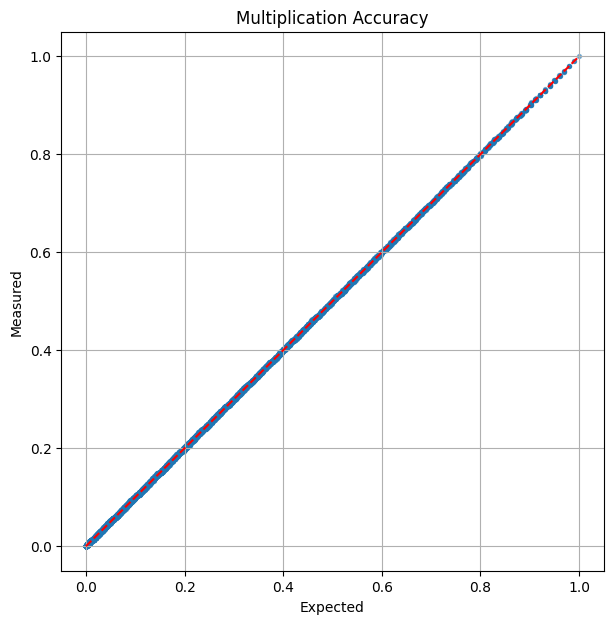

In [20]:

plt.figure(figsize=(7,7))

plt.scatter(

    mult_df["Expected"],

    mult_df["Measured"],

    s=8,

    alpha=0.5

)

plt.plot(

    [0,1],

    [0,1],

    'r--'

)

plt.xlabel("Expected")

plt.ylabel("Measured")

plt.title("Multiplication Accuracy")

plt.grid(True)

plt.show()

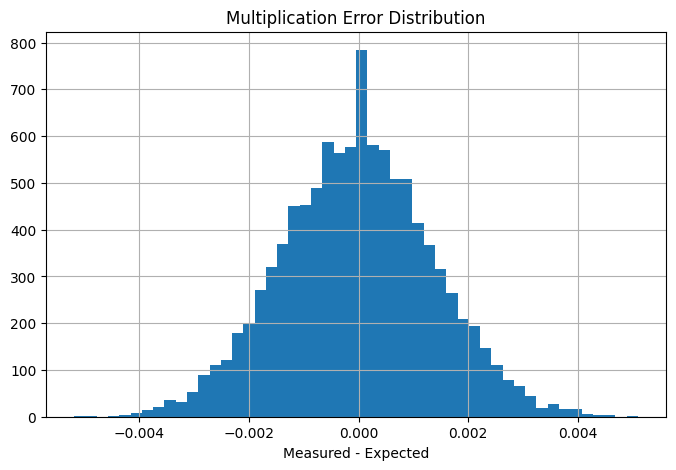

In [21]:
plt.figure(figsize=(8,5))

plt.hist(

    mult_df["Error"],

    bins=50

)

plt.grid(True)

plt.title("Multiplication Error Distribution")

plt.xlabel("Measured - Expected")

plt.show()

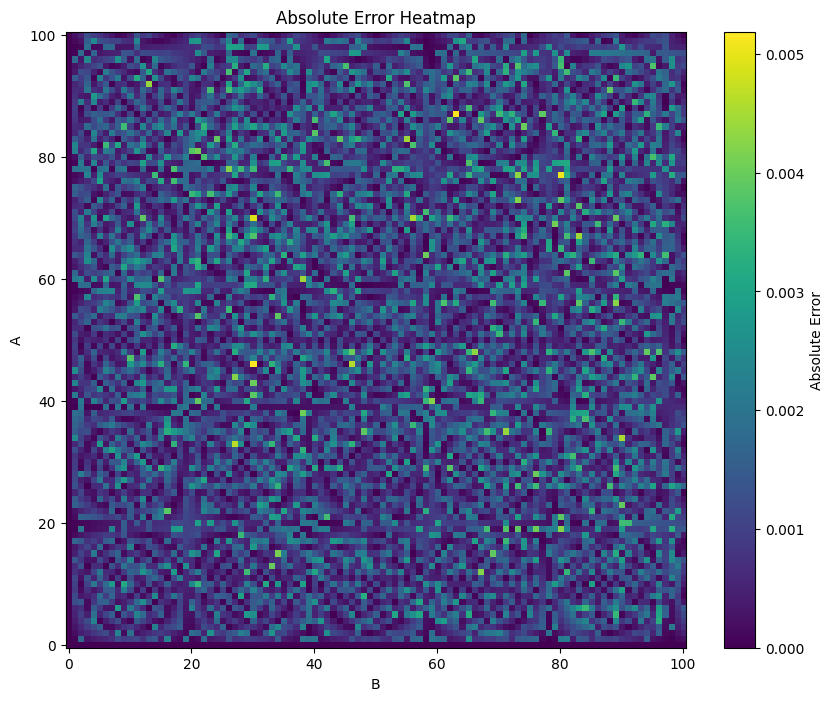

In [22]:
heat = mult_df.pivot(

    index="A",

    columns="B",

    values="Absolute Error"

)

plt.figure(figsize=(10,8))

plt.imshow(

    heat,

    origin='lower',

    aspect='auto'

)

plt.colorbar(label="Absolute Error")

plt.xlabel("B")

plt.ylabel("A")

plt.title("Absolute Error Heatmap")

plt.show()


In [23]:
rng = np.random.default_rng(123)

errors = []

for _ in tqdm(range(10000)):

    a = np.round(rng.uniform(),2)

    b = np.round(rng.uniform(),2)

    streamA = library[a]["A"]

    streamB = library[b]["B"]

    measured = np.sum(streamA & streamB)/STREAM_LENGTH

    expected = a*b

    errors.append(abs(measured-expected))

errors = np.array(errors)

print("Random MAE :",errors.mean())

print("Random Max :",errors.max())


  0%|          | 0/10000 [00:00<?, ?it/s]

Random MAE : 0.0011000990625
Random Max : 0.0051875000000000115


In [24]:
os.makedirs("metrics",exist_ok=True)

mult_df.to_csv(

    "metrics/multiplication_results.csv",

    index=False

)

print("Saved.")

Saved.


In [25]:
bitstreams = np.zeros(

    (

        len(VALUES),

        2,

        STREAM_LENGTH

    ),

    dtype=np.uint8

)

for i,v in enumerate(VALUES):

    bitstreams[i,0,:]=library[v]["A"]

    bitstreams[i,1,:]=library[v]["B"]

bitstreams.shape

(101, 2, 512)

In [26]:
np.save(

    "library/sobol_library.npy",

    bitstreams

)

print("Done.")

Done.


In [27]:
with open("library/sobol.mem","w") as f:

    for value in VALUES:

        A = ''.join(

            map(str,

                library[value]["A"])

        )

        B = ''.join(

            map(str,

                library[value]["B"])

        )

        f.write(A+"\n")

        f.write(B+"\n")

print("MEM file written.")

MEM file written.


In [28]:
with open("library/sobol.coe","w") as f:

    f.write("memory_initialization_radix=2;\n")

    f.write("memory_initialization_vector=\n")

    for idx,value in enumerate(VALUES):

        A=''.join(map(str,library[value]["A"]))

        B=''.join(map(str,library[value]["B"]))

        f.write(A+",\n")

        if idx==len(VALUES)-1:

            f.write(B+";\n")

        else:

            f.write(B+",\n")

print("COE generated.")

COE generated.


In [29]:
loaded=np.load(

    "library/sobol_library.npy"

)

print(loaded.shape)

print(np.array_equal(

    loaded,

    bitstreams

))

(101, 2, 512)
True
